# APIs
- As a data scientist or analyst it is very important that you understand your sources of data
- SOURCE OF DATA
    - something that can give data
    - examples are:
        - files like .csv files, or .sql files
        - documents have tables
        - .xsls files
    - FILES
    - DATABASES
    - APIs

- API - Application Programming Interface
- are a set of Rules or protocols, that allow softwares to share data or interact
- 

- Analogy

- Restaurant (Food) ------------- waiter ---------- User

- Website ------------- API ------------> User

#### Example of a Real-World API:

Let's say you want to get **current weather** data for your location. You can use a weather service **API** like **OpenWeatherMap** to get this information. You send a request with your location (just like ordering food), and the API sends back the weather data for that location (like receiving your meal).

Here's what happens in the background:
1. You **send a request** to the weather API with your location.
2. The API communicates with a weather database.
3. The API **sends back data** (in JSON format) with details like temperature, humidity, and forecast.


OpenWeatherMap API usage:
1. sign up to the platform
2. gives you a profile
3. create an API key (is a treasure???)

- Free platform - it allows a certain number of free requests per hour
    - one might actually buy the usage limits

### how does python talk to the internet
- DOG

In [ ]:
pip install requests

In [8]:
import requests # package that helps in sending requests to a server

# create an API endpoint to fetch something
url = "https://dog.ceo/api/breeds/image/random"

In [ ]:
response = requests.get(url)
print(response)

# response code - 200 means successful connection
# response code - 404 means Not Found (if wrong link)

<Response [200]>


The requests library uses the Response class to handle the response data from the server.
- Common HTTP Status Codes:
    - 200: OK - The request was successful.
    - 404: Not Found - The server could not find the requested page or resource.
    - 500: Internal Server Error - There was an error on the server while processing the request.

In [ ]:
print(response.status_code) # status code of response

data = response.json() # json is a javascript object notation ---- this is used for data -- stores in key value pairs
# 
print(data)

200
{'message': 'https://images.dog.ceo/breeds/schnauzer-miniature/n02097047_6567.jpg', 'status': 'success'}


In [20]:
print(type(data))
dog_url = data['message']
print(dog_url)

<class 'dict'>
https://images.dog.ceo/breeds/schnauzer-miniature/n02097047_6567.jpg


JSON - Javascript Object Notation
- a standard , lightweight text format used to exchange data
- mostly over the internet
- used extensively in APIs
- Almost every programming language has tools to read and write json type text
- 

In [24]:
import requests

url = "https://dog.ceo/api/breeds/image/random"
response = requests.get(url)
data = response.json()
dog_url = data['message']
dog_url

'https://images.dog.ceo/breeds/terrier-cairn/n02096177_2007.jpg'

In [34]:
import requests

response = requests.get("https://api.thecatapi.com/v1/images/search")
data = response.json()
data[0]['url']

'https://cdn2.thecatapi.com/images/e0g.jpg'

In [5]:
import requests
dog_url = lambda url: requests.get(url).json()['message']
dog_url("https://dog.ceo/api/breeds/image/random")

'https://images.dog.ceo/breeds/kombai/Kombai-indian-Dog.jpg'

In [6]:
import requests
cat_url = lambda url: requests.get(url).json()[0]['url']
img1 = cat_url("https://api.thecatapi.com/v1/images/search")
img1

'https://cdn2.thecatapi.com/images/XWqBv4Dnh.jpg'

https://cdn2.thecatapi.com/images/39m.jpg


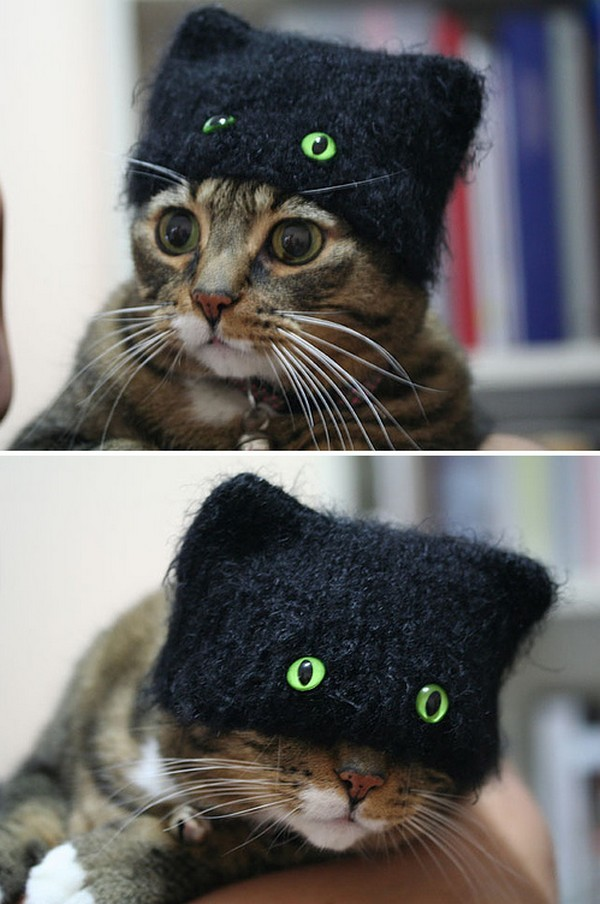

In [39]:
def fetch_img(url):
    import requests

    response = requests.get(url)
    data = response.json()
    cat_url = data[0]['url']
    image = requests.get(cat_url).content # gets us the raw content from the response

# saves the image in our workspace
# in case of an image, we need to use binary
    with open("cat_image.jpg", "wb") as f:
        f.write(image)

    # show the image
    from PIL import Image
    img = Image.open("cat_image.jpg")
    img.show()

    print(cat_url)
    return img

fetch_img("https://api.thecatapi.com/v1/images/search")

- save the image and then open it in PIL library
-
- temporary save the image as well

In [ ]:
pip install Pillow

### Function that fetches image, saves in folder, and views it

In [33]:
def fetch_img2(url):
    import requests

    response = requests.get(url)
    data = response.json()
    dog_url = data['message']
    image = requests.get(dog_url).content

    with open("dog_image.jpg", "wb") as f:
        f.write(image)

    # show the image
    from PIL import Image
    img = Image.open("dog_image.jpg")
    img.show()

    return dog_url

fetch_img2("https://dog.ceo/api/breeds/image/random")

'https://images.dog.ceo/breeds/greyhound-italian/n02091032_658.jpg'

In [40]:
# List of APIs that fetch random data

random_user_url = "https://randomuser.me/api/"
# Fetches random user profile data (name, email, phone, address)

random_quote_url = "https://api.quotable.io/random"
# Fetches a random quote with author and content

random_cat_url = "https://api.thecatapi.com/v1/images/search"
# Fetches random cat image URL and breed information

random_joke_url = "https://official-joke-api.appspot.com/random_joke"
# Fetches a random joke with setup and punchline

random_advice_url = "https://api.adviceslip.com/advice"
# Fetches random life advice slip with advice text

## Exercise - 

In [46]:
import requests
data = requests.get(random_user_url).json()

_name = data['results'][0]['name']
title = _name['title']
first_name = _name['first']
last_name = _name['last']
name = f"{title} {first_name} {last_name}"
city = data['results'][0]['location']['city']
country = data['results'][0]['location']['country']
email = data['results'][0]['email']

print(f"Name: {name}\nLives in: {city}, {country}\nEmail: {email}")

Name: Mr Sigurd Li
Lives in: Stjørdalshalsen, Norway
Email: sigurd.li@example.com


Now it's your turn!
## Weather App Project
### Fetch Weather Data Using OpenWeatherMap API and create a dataset (Advanced - Optional)

- **Objective:**
  You will create a JSON file containing weather data for multiple cities over a period of 15 minutes. This task will help you practice your skills in making API calls, handling JSON responses, and converting data into a DataFrame.

- **Cities to Include:**
  - New York, USA
  - London, UK
  - Tokyo, Japan
  - Sydney, Australia
  - Paris, France

**Instructions:**
  1. **Obtain Your API Key:**
     - Go to the [OpenWeatherMap website](https://openweathermap.org/).
     - Create a free account if you don't have one.
     - Navigate to the API section and generate your API key.
  2. **Write the Python Code:**
     - Create a Python script that performs the following:
       - Import the necessary libaries (`requests`, `json`, `pandas`).
       - Define the list of cities you want to query and your API key.
       - Set up a loop to make requests to OpenWeatherMap API every 1 minute for 15 minutes.
       - For each iteration, parse the JSON response and extract the following information:
         - City name 
         - Temperature (in Celsius)
         - Weather description
         - Humidity
         - Wind speed
         - Timestamp
       - Store this information in a list of dictionaries.
       - Convert the list of dictionaries to a DataFrame.
       - Save the DataFrame to a JSON file.
  3. **Deliverable:**
       - Store this information in a list of dictionaries.
       - Convert the list of dictionaries to a DataFrame.
       - Save the DataFrame to a JSON file."
       - You must in the end have a dataset with 15 entries of weather for each city

```python
   API
    |
    |
   Json
    |
    |
  Table

  Table --- Pandas ---- Analysis
  Table --- Matplotlib ---- Analysis via Graphs